In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb

In [23]:
df = pd.read_csv("../data/train.csv", index_col=False)
df = df.drop(columns="id")

In [24]:
print(df.shape)
print(df.duplicated().sum())
df.info()

(577347, 11)
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  object 
 9   galaxy_population  577347 non-null  object 
 10  class              577347 non-null  object 
dtypes: float64(8), object(3)
memory usage: 48.5+ MB


In [25]:
df.head(10)

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY
5,250.727869,31.756548,20.926469,19.693480,18.902361,19.247572,18.508241,0.076299,G/K,Blue_Cloud,STAR
6,0.752529,-2.936677,22.829195,22.686143,20.583886,19.781338,19.410491,0.575080,M,Red_Sequence,GALAXY
7,235.611325,39.626517,22.511467,21.480306,21.765645,21.508658,21.333476,2.159269,O/B,Blue_Cloud,QSO
8,355.359230,2.182312,20.396550,20.064767,19.892257,19.836272,19.860081,0.900087,A/F,Blue_Cloud,QSO
9,254.980080,38.743449,18.839137,17.997845,18.458894,18.229552,19.202247,0.114302,O/B,Blue_Cloud,STAR


#### Takeaways:
- The dataset is large, with 577,347 rows and 11 columns after dropping 'id'.
- There are no duplicate rows.
- The input data contains 8 numeric features and 2 categorical features.
- The target variable, 'class', is categorical and will be modeled as a multiclass classification problem.

#### Check target class distribution

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

class
GALAXY    0.653818
QSO       0.202899
STAR      0.143283
Name: proportion, dtype: float64

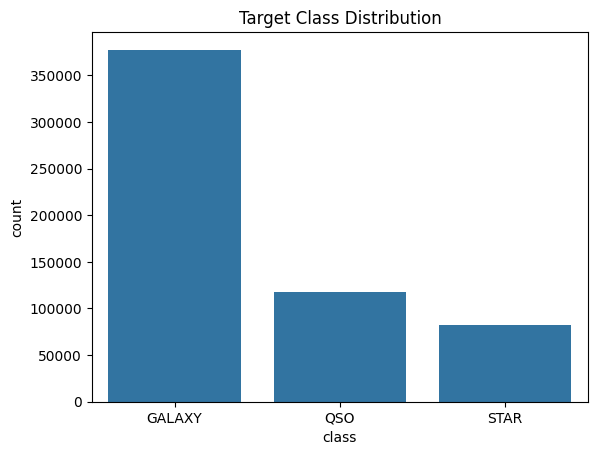

In [26]:
class_counts = df['class'].value_counts()
class_proportions = df['class'].value_counts(normalize=True)

display(class_counts)
display(class_proportions)

sns.countplot(data=df, x="class")
plt.title("Target Class Distribution")
plt.show()

#### Categorical Feature Counts

In [27]:
display(df['spectral_type'].value_counts())
display(df['galaxy_population'].value_counts())

spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64

galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64

#### Takeaways:
- The target is moderately imbalanced: GALAXY makes up 65% of the training data.
- Future train/validation splits should use stratification to preserve class proportions.
- Accuracy alone may be misleading, so log loss and class-level performance should be checked.

#### Categorical Features vs Target



In [28]:
display(pd.crosstab(df["spectral_type"], df["class"], normalize="index"))
pd.crosstab(df["galaxy_population"], df["class"], normalize="index")

class,GALAXY,QSO,STAR
spectral_type,,,
A/F,0.198490,0.503709,0.297801
G/K,0.567750,0.192739,0.239511
M,0.949559,0.012821,0.037620
O/B,0.082803,0.710836,0.206361


class,GALAXY,QSO,STAR
galaxy_population,,,
Blue_Cloud,0.345106,0.420022,0.234873
Red_Sequence,0.902846,0.027753,0.069401


#### Takeaways:
- `spectral_type` appears strongly related to the target. M-type observations are mostly GALAXY, whereas O/B observations are mostly QSO.
- `galaxy_population` is also informative: Red_sequence is mostly GALAXY, whilst Blue_Cloud is more mixed across classes.
- Both features should be retained.

#### Numeric Feature Averages by Target Class

In [29]:
numerical_features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
df.groupby("class")[numerical_features].mean()

,alpha,delta,u,g,r,i,z,redshift
class,,,,,,,,
GALAXY,178.557241,21.033443,22.989160,21.270147,19.860511,19.068222,18.629897,0.509026
QSO,189.665998,25.811829,21.724756,21.160314,20.918809,20.767309,20.602139,1.875641
STAR,184.178832,19.858725,20.960388,19.591033,19.075853,18.830555,18.707180,0.068115


#### Takeaways:
- `redshift` differs substantially by class, especially QSO compared to GALAXY and STAR.
- Further insights need visualizations of distributions.

#### Visualizing the Distributions

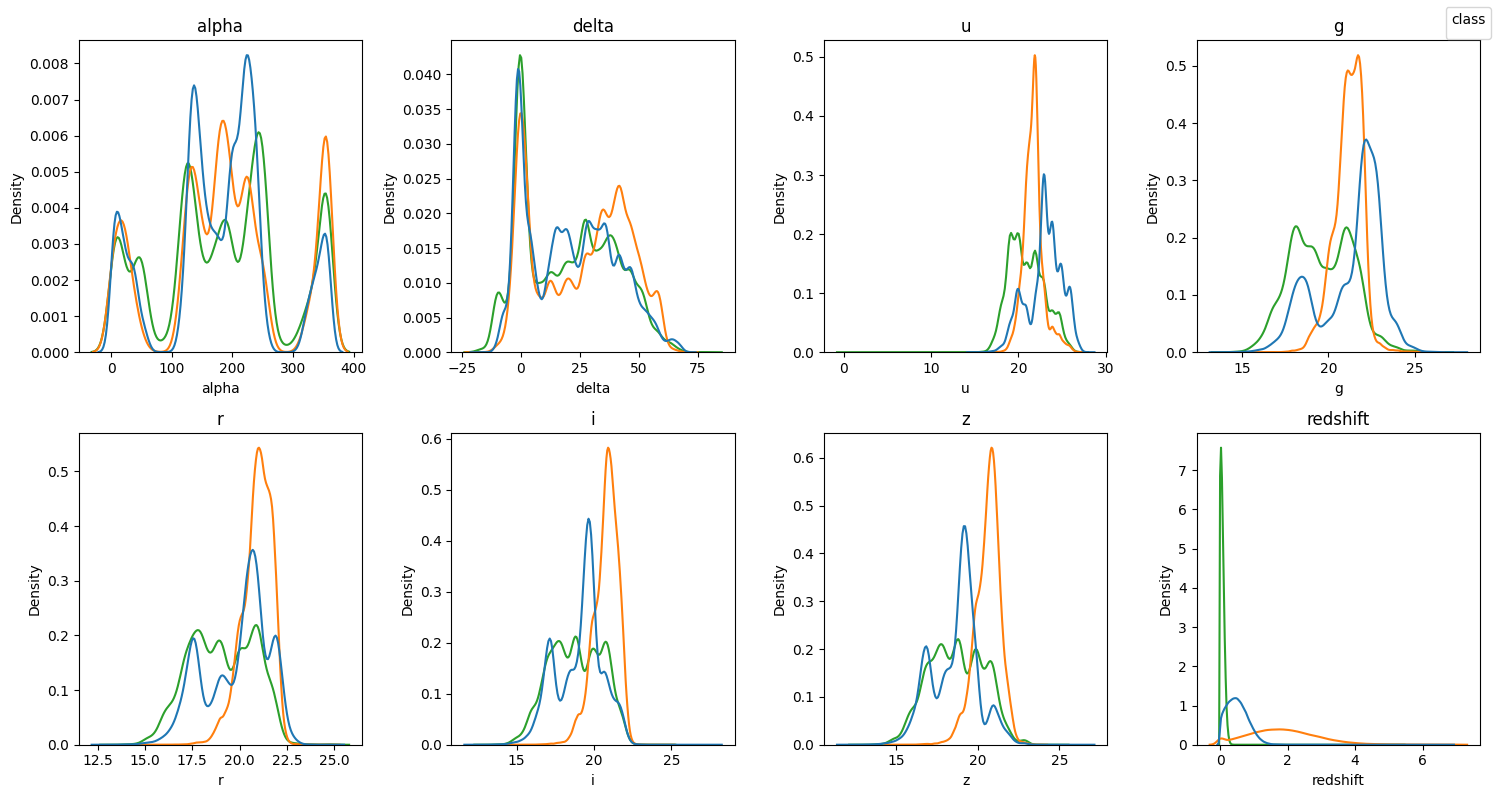

In [30]:
fig, axes = plt.subplots(2,4, figsize=(15,8))
axes = axes.ravel()

for ax, col in zip(axes, numerical_features):
    
    sns.kdeplot(data=df, x=col, hue="class", common_norm=False, ax=ax, legend=False)
    ax.set_title(col)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="class", loc="upper right")
plt.tight_layout()
plt.show()

#### Takeaways:
- `alpha` and `delta` have boardly similar distributions across classes, but some regions may still provide useful signals.
- The photometric bands show visible class separation, especially as wavelength increases from `u` toward `z`.
- `i` and `z` are incredibly similar distributions, so it is worth testing whether removing one affects validation performance.
- `redshift` appears highly informative, especially for separating STAR from QSO and GALAXY.

Encoding alpha with the sinus function is important due to them being recorded in degrees. The model will not be able to tell that 360 and 0 are the same. Delta does not have the same issue as it seems to be within -25 to 75 degrees.

In [174]:
df["alpha_sin"] = np.sin(np.deg2rad(df["alpha"]))

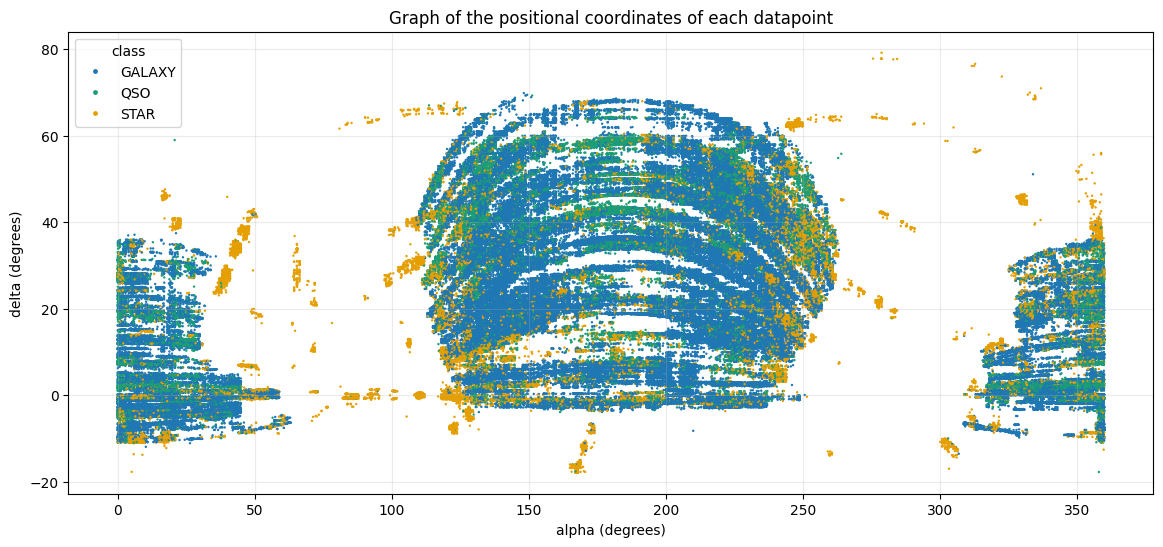

In [32]:
palette = {
    "GALAXY": "#1f77b4",
    "QSO": "#1b9e77",
    "STAR": "#e69f00"
}

#plot_df = df.sample(50000, random_state=42)

plt.figure(figsize=(14, 6))

sns.scatterplot(
    data=df,
    x="alpha",
    y="delta",
    hue="class",
    palette=palette,
    alpha=1,
    s=3,
    linewidth=0
)

plt.title("Graph of the positional coordinates of each datapoint")
plt.xlabel("alpha (degrees)")
plt.ylabel("delta (degrees)")
plt.legend(title="class", markerscale=2)
plt.grid(True, alpha=0.25)

plt.show()

Graphing Alpha and Delta reveal a graph that doesn't show great promise for predictive power. This will be further tested in an ablation study.

#### Experimenting with Photometric differences

In [33]:
df["u_g"] = df["u"] - df["g"]
df["g_r"] = df["g"] - df["r"]
df["r_i"] = df["r"] - df["i"]
df["i_z"] = df["i"] - df["z"]
df["u_z"] = df["u"] - df["z"]

In [34]:
colour_mix = ['u_g', 'g_r', 'r_i', 'i_z', 'u_z']
df.groupby("class")[colour_mix].mean()

,u_g,g_r,r_i,i_z,u_z
class,,,,,
GALAXY,1.719013,1.409635,0.792290,0.438324,4.359263
QSO,0.564442,0.241505,0.151500,0.165170,1.122616
STAR,1.369355,0.515179,0.245298,0.123375,2.253208


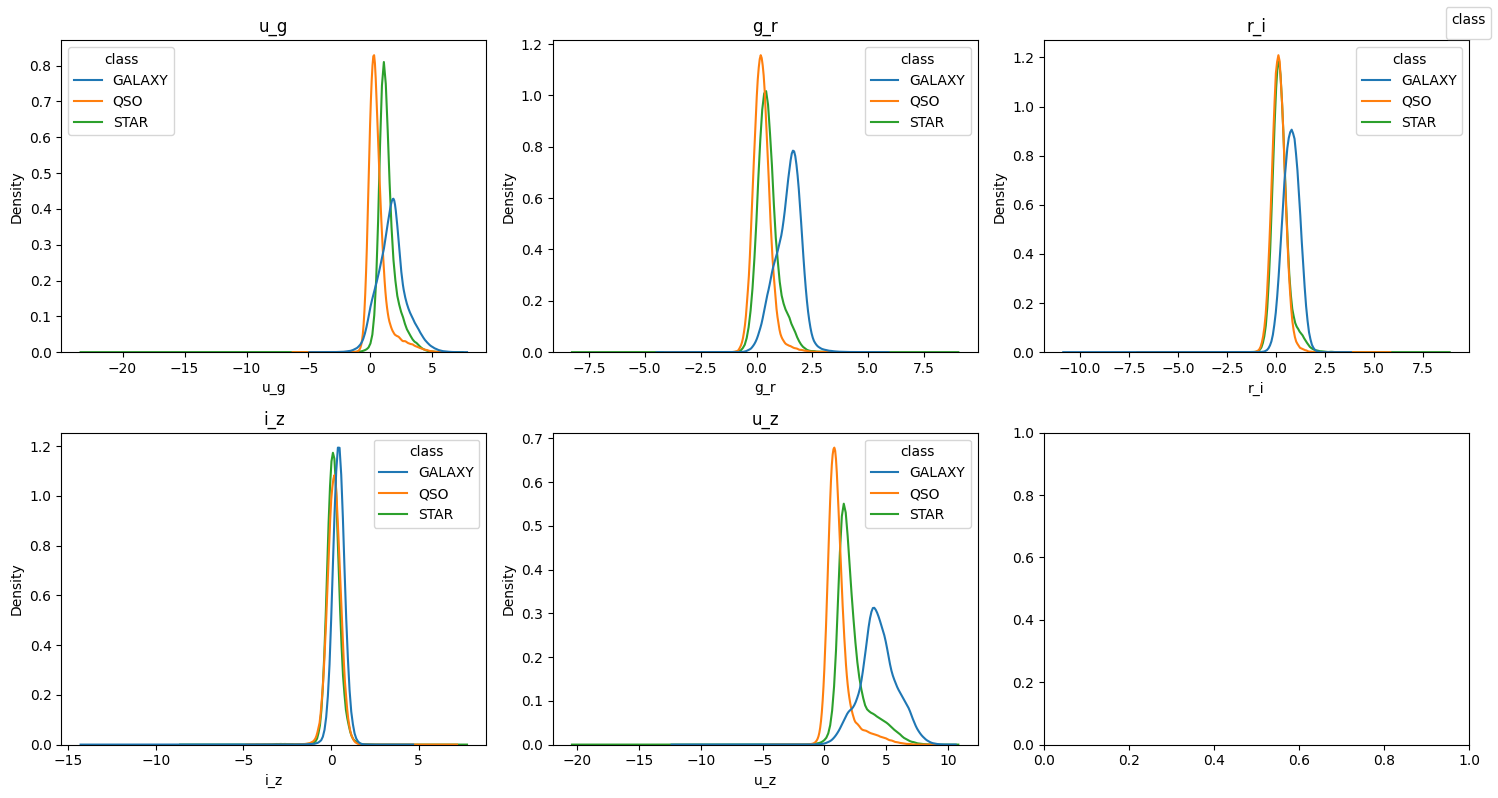

In [35]:
figs, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.ravel()

for ax, col, in zip(axes, colour_mix):
    sns.kdeplot(data=df, x=col, hue="class", ax=ax, common_norm=False)
    ax.set_title(col)

handles, labels = axes[0].get_legend_handles_labels()
figs.legend(handles, labels, title="class", loc="upper right")

plt.tight_layout()
plt.show()

#### Takeaways:
- The photometric differences help separate `GALAXY`.
- `u_g` and `u_z` are most informative for distinguishing `QSO` from `STAR`.
- These engineered features should be tested in the preprocessing experiments notebook

#### Correlation Heatmap

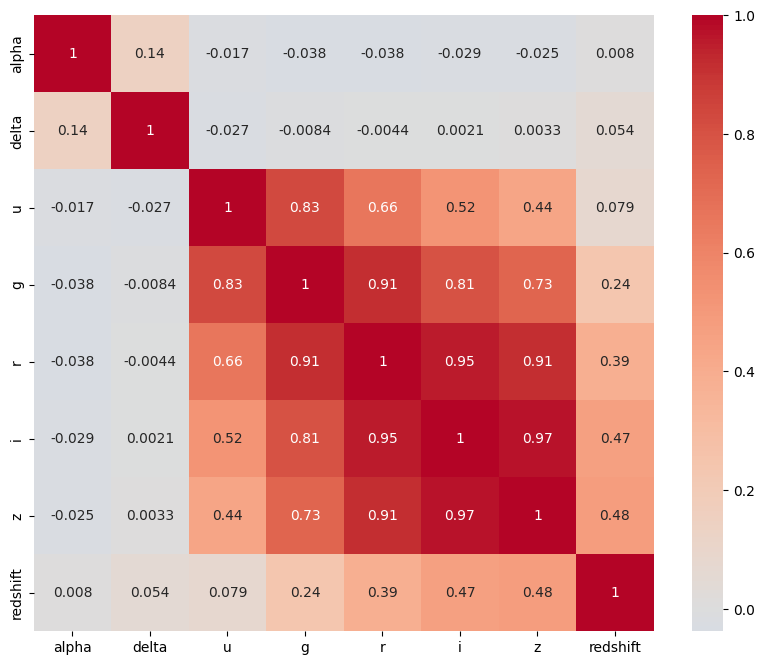

In [36]:
numeric_cols = df.select_dtypes("number").columns

plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.show()

#### Takeaways:
- `alpha` and `delta` are only slightly correlated with each other and mostly uncorrelated with other numeric features.
- The photometric bands are highly correlated, especially `r`, `i` and `z`. 
This suggests an ablation study of the photometric bands is worthwhile, but they should not be removed automatically because correlated bands may still contain useful information. 


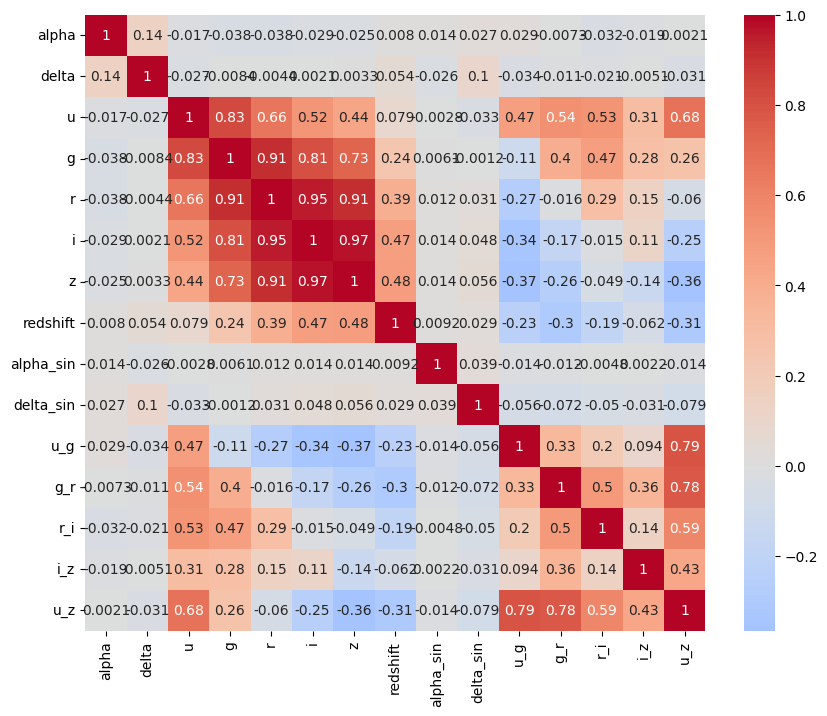

In [157]:
numeric_cols = df.select_dtypes("number").columns

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.show()

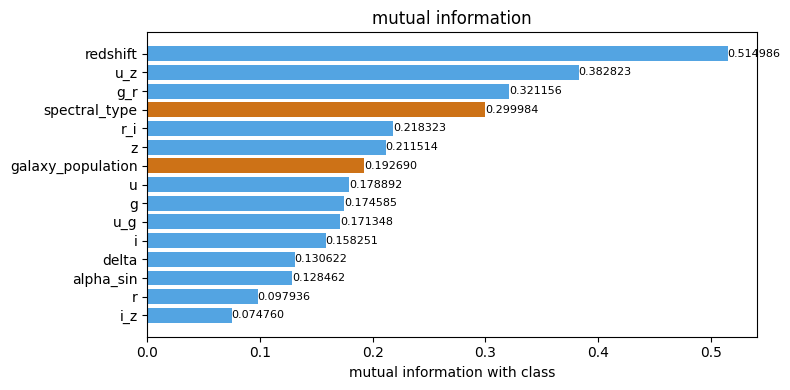

In [175]:
from sklearn.feature_selection import mutual_info_classif
y = df["class"].values
mi_feats = ['redshift', 'u', 'g', 'r', 'i', 'z', 'alpha_sin', 'delta',
            'spectral_type', 'galaxy_population', 'u_g', 'g_r',
            'r_i', 'i_z', 'u_z']
Xmi = df[mi_feats].copy()

for c in ['spectral_type', 'galaxy_population']:
    Xmi[c] = Xmi[c].astype("category").cat.codes

disc = [f in ('spectral_type', 'galaxy_population') for f in mi_feats]
mi = pd.Series(mutual_info_classif(Xmi, y, discrete_features=disc, random_state=1), 
               index=mi_feats).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
bar_c = ["#CD7217" if f in ('spectral_type', 'galaxy_population') else 
         "#53A4E2" for f in mi.index]
ax.barh(mi.index, mi.values, color=bar_c)
for yi, v in enumerate(mi.values):
    ax.text(v, yi, f"{v:2f}", va="center", fontsize=8)
ax.set_xlabel("mutual information with class")
ax.set_title("mutual information")
plt.tight_layout(); plt.show()

This mutual information analysis indicates that redshift has the strongest individual association with the target class, followed by the colour mixes u_z and g_r. The synthetic categorical features also perform well in this test. Lastly, the positional features don't seem to be very helpful.

Ablation study

In [159]:
from sklearn.model_selection import StratifiedKFold 
from sklearn.metrics import balanced_accuracy_score
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from tqdm.notebook import tqdm
from sklearn.ensemble import HistGradientBoostingClassifier

In [160]:
#Baseline: RedShift -> With colors 

In [176]:
groups = {
    'redshift' : ['redshift'],
    'synthetic' : ['spectral_type', 'galaxy_population'],
    'colour' : ['u', 'g', 'r', 'i', 'z'],
    'position' : ['alpha_sin', 'delta'],
    'colour mixes' : colour_mix,
}

In [162]:
params = dict(
    objective="multiclass",
    num_class=3,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,          # row bagging
    subsample_freq=1,
    colsample_bytree=0.8,   # feature bagging
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=1,
    n_jobs=-1,
    verbose=-1
)

In [ ]:
groups = {
    'baseline' : [],
    'redshift' : ['redshift'],
    'synthetic' : ['spectral_type', 'galaxy_population'],
    'colour' : ['u', 'g', 'r', 'i', 'z'],
    'position' : ['alpha_sin', 'delta'],
    'colour mixes' : colour_mix,
}

experiments = {
    'redshift' : ['redshift'],
    #'+ diff colour' : ['redshift', 'u_g', 'g_r', 'r_i', 'i_z', 'u_z'],
    'redshift + colour' : ['redshift', 'u', 'g', 'r', 'i', 'z'],
    'colours mixes only + position' : ['redshift', 'u_g', 'g_r', 'r_i', 'i_z', 'u_z', 'alpha', 'delta'],
    'both colours + position' : ['redshift', 'u_g', 'g_r', 'r_i', 'i_z', 'u_z', 'u', 'g', 'r', 'i', 'z', 'alpha', 'delta'],
    'redshift + colour + position' : ['redshift', 'u', 'g', 'r', 'i', 'z', 'alpha', 'delta'],
    'encoded position instead' : ['redshift', 'u', 'g', 'r', 'i', 'z', 'alpha_sin', 'delta'],
}
all_features = [f for group in groups.values()
                for f in group]

le = LabelEncoder()

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

df_lgbm = df.copy()

for col in ["spectral_type", "galaxy_population"]:
    df_lgbm[col] = df_lgbm[col].astype("category")

results = []
oofs = []
oofs_p = []
y = le.fit_transform(df_lgbm["class"])
for values in tqdm(experiments.values(), desc="feature_groups"):
    oof_preds = np.empty(len(y), dtype=object); temp = []
    oof_probs = np.empty((len(y), 3), dtype=object)
    #f = [x for x in all_features if x not in values] Removes
    X = df_lgbm[values]
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        
        X_train, X_test, y_train, y_test = X.iloc[train_idx], X.iloc[test_idx], y[train_idx], y[test_idx]
        cat_features = [
            col for col in groups["synthetic"]
            if col in X_train.columns
        ]
        train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features)
        model = lgb.train(params, train_data)

        #model = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08, random_state=1,
        #                                   early_stopping=True, categorical_features=cat_features or None)
        #model.fit(X_train, y_train)
        probs = model.predict(X_test)
        preds = probs.argmax(axis=1)
        oof_preds[test_idx] = preds; oof_probs[test_idx] = probs
        temp.append(balanced_accuracy_score(y_test, preds))
    results.append(temp)
    oofs.append(oof_preds)
    oofs_p.append(oof_probs)





feature_groups:   0%|          | 0/6 [00:00<?, ?it/s]

This test shows what happens if each group of features is removed.

In [ ]:
for result, group in zip(results, groups.keys()):
    mean = np.mean(result)
    std = np.std(result)
    print(f"{group} | mean: {mean} | std: {std}")

baseline | mean: 0.8038329391866137 | std: 0.0030152335052945284
redshift | mean: 0.9362737522407911 | std: 0.00020387866153213991
synthetic | mean: 0.9551811095476237 | std: 0.0007249305290833952
colour | mean: 0.9370486683333024 | std: 0.00032022280083369173


- Here we see that the removal of redshift significantly lowers the strength of the model. 
- Synthetic Features do not appear to have any impact on the strength of the model.
- Colour features have the second largest impact on performance.
- Position features and the colour mix features have only a slight impact on performance.

In [181]:
previous_mean = 0
for result, experiment in zip(results, experiments.keys()):
    mean = np.mean(result)
    std = np.std(result)
    print(f"{experiment} | mean: {mean} | std: {std} | increase in mean: {mean- previous_mean}")
    previous_mean = mean

redshift | mean: 0.8038329391866137 | std: 0.0030152335052945284 | increase in mean: 0.8038329391866137
redshift + colour | mean: 0.9362737522407911 | std: 0.00020387866153213991 | increase in mean: 0.13244081305417743
 colours mixes only | mean: 0.9468911551149107 | std: 0.0008644912936198563 | increase in mean: 0.010617402874119608
both colours | mean: 0.955255493265898 | std: 0.0007353680039904629 | increase in mean: 0.00836433815098725
redshift + colour + position | mean: 0.9551811095476237 | std: 0.0007249305290833952 | increase in mean: -7.438371827428458e-05
encoded position instead | mean: 0.9534501784944596 | std: 0.0002784916167249028 | increase in mean: -0.0017309310531641309


It seems that the core of redshift, colour, and position features create the strongest base with a performance of about 0.955. Encoding alpha does not seem to be significantly impactful.

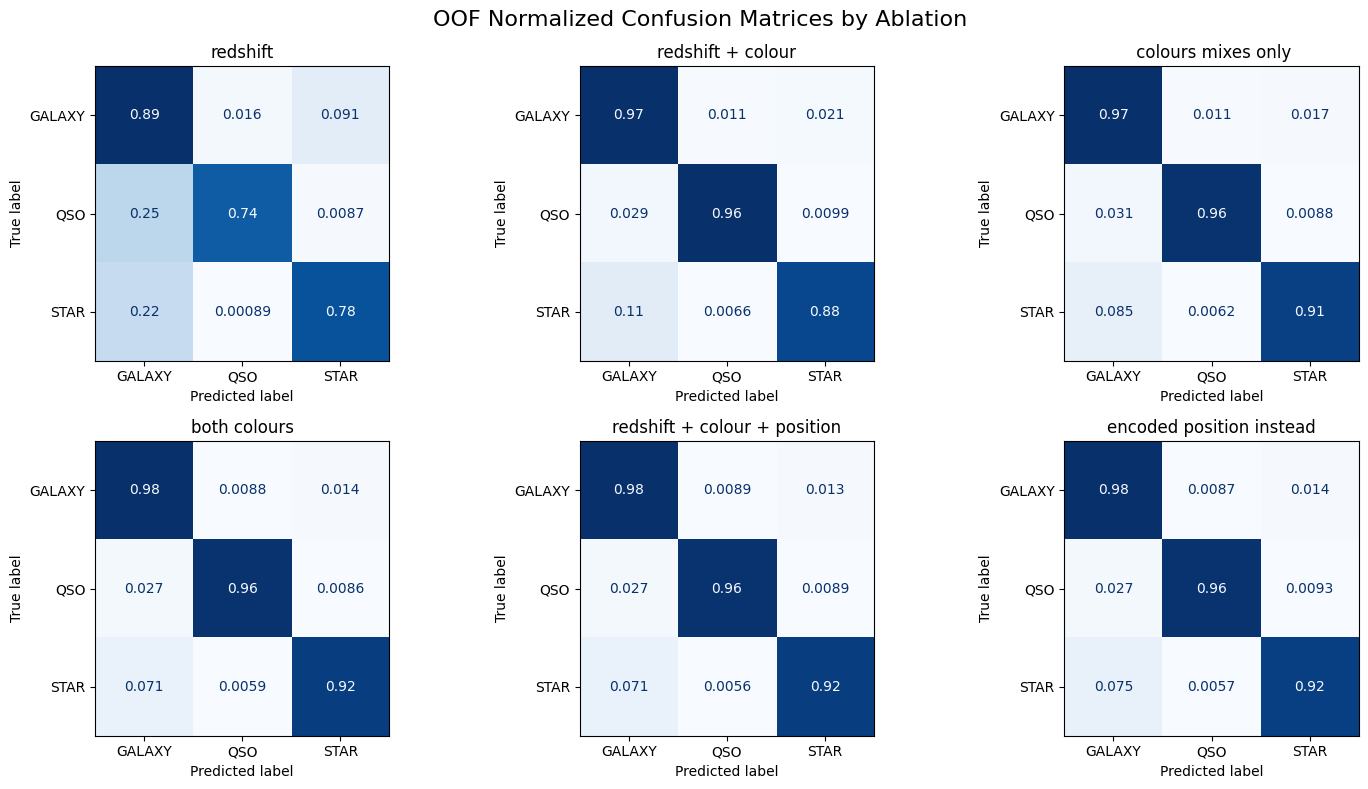

In [182]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import math

n = len(oofs)
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.ravel()

for ax, oof_pred, experiment in zip(axes, oofs, experiments.keys()):
    ConfusionMatrixDisplay.from_predictions(
        le.inverse_transform(y),
        le.inverse_transform(oof_pred.astype(int)),
        normalize="true",
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    ax.set_title(f"{experiment}")

for ax in axes[len(oofs):]:
    ax.axis("off")

fig.suptitle("OOF Normalized Confusion Matrices by Ablation", fontsize=16)
plt.tight_layout()
plt.show()

Takeaways:
- redshift is very strong on GALAXY.
- When adding the colour features, you get a strong GALAXY and QSO predictor.
- STAR is the weakest link -> It needs to be boosted as the best way to raise balanced accuracy score is by raising the weakest link.
- Positional metrics help STAR in a sizeable manner.
- Diff colours doesn't seem to be useful.

In [169]:
from scipy.optimize import differential_evolution


oof = oofs_p[-2]
def objective(params):
    qso_weight, star_weight = params

    weights = np.array([
        1.0,
        qso_weight,
        star_weight
    ])

    adjusted_predictions = (
        oof * weights
    ).argmax(axis=1)

    score = balanced_accuracy_score(
        y,
        adjusted_predictions
    )

    # scipy minimizes, so return the negative score
    return -score


result = differential_evolution(
    objective,
    bounds=[
        (0.5, 2.0),  # QSO weight
        (0.5, 2.0)   # STAR weight
    ],
    seed=42,
    tol=1e-7
)

best_weights = np.array([
    1.0,
    result.x[0],
    result.x[1]
])

best_score = -result.fun

print("Best weights:", best_weights)
print("Best OOF balanced accuracy:", best_score)


Best weights: [1.         1.93916436 1.99667318]
Best OOF balanced accuracy: 0.9624913742545699


In [170]:
rX_test = pd.read_csv("../data/test.csv", index_col=False)

In [171]:
rX_test = rX_test.drop(columns=['spectral_type', 'galaxy_population'])
ids = rX_test.pop('id')

rX_test = rX_test[experiments['redshift + colour + position']]

In [172]:
best_weights

array([1.        , 1.93916436, 1.99667318])

In [173]:
final_X = df[experiments['redshift + colour + position']]
train_data = lgb.Dataset(final_X, label=y)
model = lgb.train(params, train_data)
probs = model.predict(rX_test)
adjusted_probs = probs * best_weights
preds = adjusted_probs.argmax(axis=1)

test_pred_labels = le.inverse_transform(preds)

submissions = pd.DataFrame(
    {
        'id': ids,
        'class': test_pred_labels
    }
)
submissions.to_csv("basic_attempt_submission.csv", index=False)

This submission had a public score of 0.9628 and private score of 0.9633